In [1]:
# Importing the libraries
import os 
import sys
import time
import warnings
os.system('clear')
warnings.filterwarnings("ignore")
import argparse

import torch 
# import torch.nn as nn
# import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
torch.set_printoptions(threshold=512, linewidth=512)

hostname = os.uname()
if 'tycho' in hostname:
    # Common folder is already in the path
    pass
elif 'tedtop' in hostname:
    print('Setting up paths for tedtop')
    sys.path.append('/home/fedor-tairli/work/CDEs/Dataset/')
elif 'ycho' in hostname: 
    sys.path.append('/remote/tychodata/ftairli/work/Projects/Common/')
else:
    # Assume KIT CLuster
    sys.path.append('/cr/work/tairli/CDEs/Dataset/')



In [2]:
def in_jupyter():
    try:
        from IPython import get_ipython
        shell = get_ipython().__class__.__name__
        return shell == "ZMQInteractiveShell"
    except:
        return False

print(f'Running in Jupyter: {in_jupyter()}')

Running in Jupyter: True


In [3]:
ModelPath = os.path.abspath('../Models') + '/'
sys.path.append(ModelPath)
# Dataset modules
from Dataset2 import DatasetContainer, ProcessingDatasetContainer
from DataGenFunctions import Pass_Main,Pass_Aux,Pass_Truth,Pass_Rec,Pass_Graph,Pass_MetaData,Clean_Data

def LoadProcessingDataset(Path_To_Data,Path_To_Proc_Data,RunNames,RecalculateDataset = False,NeedTraces = False,OptionalName = None):
    if OptionalName is None: OptionalName = 'CurrentProcessingDataset'
    '''Loads the dataset from the path and returns a ProcessingDatasetContainer'''
    # Check if path to data endswith '/'
    if Path_To_Data     .endswith('/'):Path_To_Data      = Path_To_Data[:-1]
    if Path_To_Proc_Data.endswith('/'):Path_To_Proc_Data = Path_To_Proc_Data[:-1]
    
    
    if (not RecalculateDataset) and (os.path.exists(Path_To_Proc_Data+f'/{OptionalName}.pt')):
        print(f'Loading Dataset {OptionalName}')
        Dataset = torch.load(Path_To_Proc_Data+f'/{OptionalName}.pt', weights_only=False)
        # Dataset.Truth_Keys = ('x','y','z','SDPPhi','CEDist')
        # Dataset.Truth_Units =('','','','rad','m')
        # torch.save(Dataset,Path_To_Proc_Data+f'/{OptionalName}.pt')
        # print('Dataset Loaded, and saved with adjusted Truth_Keys and Truth_Units')
    else:
        RecalculateDataset = True

    if RecalculateDataset:
        print('Recalculating Dataset')
        GlobalDataset = DatasetContainer()
        GlobalDataset.Load(Path_To_Data,RunNames,LoadTraces=NeedTraces)
        Dataset = ProcessingDatasetContainer()
        Dataset.set_Name(GlobalDataset.Name)

        # Pass the data to the ProcessingDataset

        Pass_Main (GlobalDataset,Dataset)
        print()
        Pass_Aux  (GlobalDataset,Dataset)
        print()
        Pass_Truth(GlobalDataset,Dataset)
        print()
        Pass_Rec  (GlobalDataset,Dataset)
        print()
        Pass_Graph(GlobalDataset,Dataset)
        print()
        Pass_MetaData(GlobalDataset,Dataset)
        print()

        # Save the dataset
        Dataset.Save(Path_To_Proc_Data,Name = OptionalName)
        print(f'Dataset used graphs = {Dataset.GraphData}')
    Clean_Data(Dataset)
    return Dataset


# parser = argparse.ArgumentParser()
# parser.add_argument('-','--bottlenecksize', type=int, default=None, help='Size of the bottleneck layer')
# parser.add_argument('--selectnetwork', type=int, default=None, help='Select Network to train')
# args = parser.parse_args()
# BottleNeckSize = args.bottlenecksize
# SelectNetwork = args.selectnetwork

SelectNetwork = None
BottleNeckSize = None


In [4]:
# Flags
Set_Custom_Seed      = False
Use_Test_Set         = False
Use_All_Sets         = True
Dataset_RandomIter   = True
RecalculateDataset   = False
NeedTraces           = True
LoadModel            = False # Can be bool or str path to model/tracker
# LoadModel = '/remote/tychodata/ftairli/work/CDEs/
DoNotTrain           = False
DatasetName          = 'Autoencoder_TimeFit_Dataset' #No / or .pt JUST NAME, eg GraphStructure  Use None to save as default

Debug_Mode           = False
Notebook_Retrain     = False

if Debug_Mode: 
    Use_All_Sets = False
    Use_Test_Set = True

if DoNotTrain: assert RecalculateDataset, 'Recalculate Dataset must be True if DoNotTrain is True'

if Set_Custom_Seed:
    seed = 1234
    print('      Setting Custom Seed')
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Save Paths
SavePath     = os.path.abspath('../Models/') + '/'
plotSavePath = None # os.path.abspath('../Results/TrainingPlots/') + '/' # or "None" to not make plots
LogPath      = os.path.abspath('../../TrainingLogs/') + '/'
# Check that all the paths exist
assert os.path.exists(SavePath)     , f'SavePath {SavePath} does not exist'
assert os.path.exists(LogPath)      , f'LogPath {LogPath} does not exist'


if plotSavePath != None:  # Purge the directory
    assert os.path.exists(plotSavePath) , f'plotSavePath {plotSavePath} does not exist'
    os.system(f'rm -r {plotSavePath}')
    os.system(f'mkdir {plotSavePath}')

# Reading the dataset    
Path_To_Data      = os.path.abspath('../Data') + '/'
Path_To_Proc_Data = os.path.abspath('../Data') + '/'

if Use_Test_Set:
    RunNames = 'EPOSLHC_R_Test'
    if "test" not in DatasetName.lower(): DatasetName += '_Test'
else:
    if Use_All_Sets:
        RunNames = ['EPOSLHC_R_Run010','EPOSLHC_R_Run030','EPOSLHC_R_Run080','EPOSLHC_R_Run090']
    else:
        RunNames = ['EPOSLHC_R_Run010']

if SelectNetwork == -1:
    DoNotTrain = True

if DoNotTrain: print('No Training will be done, Just Reading the Dataset')
Dataset = LoadProcessingDataset(Path_To_Data,Path_To_Proc_Data,RunNames,RecalculateDataset = RecalculateDataset,NeedTraces = NeedTraces,OptionalName = DatasetName)
Dataset.AssignIndices()
Dataset.RandomIter = Dataset_RandomIter



Recalculating Dataset
Loading EPOSLHC_R_Run010
Loading EPOSLHC_R_Run030
Loading EPOSLHC_R_Run080
Loading EPOSLHC_R_Run090
    Processing event 816100/816108
    Processing Aux 816100 / 816108
    Processing event 816100/816108



Dataset used graphs = True


In [5]:
Dataset.BatchSize = 1

for i,(_, BatchMains, BatchAux, BatchTruth, _) in enumerate(Dataset):
    print(f'Batch {i}:',end='\r')
    if torch.any(torch.isnan(BatchAux)) or torch.any(torch.isnan(BatchTruth)):
        print('NaN values found in the dataset')
    for A_main in BatchMains:
        for key, val in A_main.items():
            try:
                if torch.any(torch.isnan(val)):
                    print(f'{key}: {val}')
                    print(f'Key {key} has nans : value {val}')
            except:
                print(f'{key}: {val}')
                print(f'Key {key} has nans : value {val}')
    # break
    

In [142]:
816107//255


3200

In [6]:
Notebook_Retrain     = False

In [150]:

if not DoNotTrain:
    # import model
    import importlib
    import TrainingModule2 as TrainingModule
    importlib.reload(TrainingModule)
    Train = TrainingModule.Train
    Tracker = TrainingModule.Tracker

    import Model_Autoencoder
    importlib.reload(Model_Autoencoder)
    
    Loss_function = Model_Autoencoder.Loss_class
    
    validate = Model_Autoencoder.Validate_class
    metric   = Model_Autoencoder.Metric_class

    # Model_Autoencoder_TimeFit_Recursive = Model_Autoencoder.Model_Autoencoder_TimeFit_Recursive
    Model_Latent_Iterator_only_geometry = Model_Autoencoder.Model_Latent_Iterator_only_geometry
    
    
    Models = [
        # Model_Autoencoder_TimeFit,
        # Model_Autoencoder_TimeFit_withGeometry,
        # Model_Autoencoder_TimeFit_Recursive,
        Model_Latent_Iterator_only_geometry
    ]
    
    if SelectNetwork is not None:
        assert SelectNetwork < len(Models), f'SelectNetwork {SelectNetwork} is out of range, max is {len(Models)-1}'
        Models = [Models[SelectNetwork]]
        print(f'Selected Model: {Models[0].Name}')
    # If none, then train all the models

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = 'cpu'
    print(f'Using device: {device}')

    Model_Parameters = {
        'in_main_channels'        : (3,)  ,
        'pixel_embedding_size'    : 32,
        'latent_space_size'       : 16 if BottleNeckSize is None else BottleNeckSize,
        'Train_Type'              : 'Geometry', # Profile, Geometry or Both
        'N_dense_nodes'           : 64,
        'N_heads'                 : 4,
        'max_latent_iterations'   : 5, 
        'latent_space_activation' : torch.nn.GELU , # eg. torch.nn.ReLU, torch.nn.GELU, torch.nn.SiLU
        
        'PredStyle'               : 'SimpleGeometry',
        'OutWeights'              : torch.tensor([1.0,0.0,0.0]), # 0.0 or 1.0

        'in_node_channels': 5     ,
        'in_aux_channels' : 0     ,
        'in_edge_channels': 2     ,
        'N_kernels'       : 128   , 
        'N_LSTM_nodes'    : 5     ,
        'N_LSTM_layers'   : 3     ,
        'kernel_size'     : 10    ,
        'conv2d_init_type': 'normal',
        'model_Dropout'   : 0.2 ,
        'Debug_Mode'      : Debug_Mode,
    }

    Training_Parameters = {
        'LR': 0.0001,
        'epochs': 150,
        'BatchSize': 64,
        'accumulation_steps': 1,
        'epoch_done': 0,
        'batchBreak': 1e99,
        'ValLossIncreasePatience': 5,
        'Optimiser': 'Adam',
        'Debug_Mode': Debug_Mode ,
        # Loss settings
        'T_G_Loss_ratio'  : torch.tensor(1.0)   , # Between 1 and 0, 1 means only care about Time loss, 0 only geom loss
        'Rec_Loss_Weight' : torch.tensor(1.0)   , # Weight of the profile Rec vs Acc losses - 1=Equal, 2= Double the Rec Loss, 0.5 = Half the Rec Loss
        
        'Train_Type'      : Model_Parameters['Train_Type'] ,   # ###### CHECK THESE ARE FINE WITH THE ABOVE ##### #
        'OutWeights'      : Model_Parameters['OutWeights'] , 
        'PredStyle'       : Model_Parameters['PredStyle']  ,
    }

    if not Set_Custom_Seed: # Manually reset the seed, because some functions called torch.manual_seed before which changes it globaly
        seed = int(time.time())
        print(f'      Setting Random Seed to {seed}')
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    for Model in Models:
        if (not Notebook_Retrain) or (not in_jupyter()) or 'model' not in globals():
            model = Model(**Model_Parameters).to(device)
            if LoadModel:
                if type(LoadModel) == bool and os.path.exists(ModelPath+model.Name+'.pt'):
                    model = torch.load(ModelPath+model.Name+'.pt')
                    tracker = torch.load(ModelPath+model.Name+'_Tracker.pt')
                    print(f'Loaded Model: {model.Name}')
                elif type(LoadModel) == str and os.path.exists(LoadModel):
                    if LoadModel.endswith('Tracker.pt'):
                        donation_model_tracker = torch.load(LoadModel)
                        Model_state = donation_model_tracker.ModelStates[-1]
                        Model_Parameters['RegressionBlockWeighs'] = Model_state['RegressionBlockWeighs']
                        model = Model(**Model_Parameters).to(device)
                    else:
                        donation_model = torch.load(LoadModel)
                        Model_Parameters['RegressionBlockWeighs'] = donation_model.state_dict()
                        model = Model(**Model_Parameters).to(device)
                else:
                    print(f'Could not find model at {ModelPath+model.Name+".pt"}, training from scratch')
        else:
            print('Notebook Retrain Mode: Skipping model Loading and training the old one')

        print('Training Model')
        print()
        print('Model Description')
        print(model.Description)
        print()
        # set default optimiser and overwrite if needed (basically should always be Adam)
        optimiser = optim.Adam(model.parameters(), lr=Training_Parameters['LR'])
        if Training_Parameters['Optimiser'] == 'SGD' : optimizer = optim.SGD (model.parameters(), lr=Training_Parameters['LR'], momentum=0.9)
        

        gamma = 0.001**(1/30) if Training_Parameters['epochs']>30 else 0.001**(1/Training_Parameters['epochs']) # Reduce the LR by factor of 1000 over 30 epochs or less
        print(f'Gamma in LR Reduction: {gamma}')
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma = gamma, last_epoch=-1)


        print('Training model: '     ,model.Name)
        print('Accumulation Steps: ' ,Training_Parameters['accumulation_steps'])
        Dataset.BatchSize =           Training_Parameters['BatchSize']
        print('Batch Size: '         ,Dataset.BatchSize)

        if plotSavePath != None : print(f'Plot Save Path: {plotSavePath}')
        else: print('Plots will not be saved')
        if (LogPath != None) and not Debug_Mode: print(f'Log Path: {LogPath}')
        else: print('Logs will not be saved')


        if Debug_Mode: 
            print(f'\n\n Begining training in Debug Mode \n\n')

        model,tracker = Train(model,Dataset,optimiser,scheduler,Loss_function,validate,metric ,Tracker,device = device,\
                            plotOnEpochCompletionPath=plotSavePath,Training_Parameters=Training_Parameters,Model_Parameters=Model_Parameters,LogPath=LogPath)
        
        if not Debug_Mode:
            torch.save(model  ,SavePath+model.Name+'.pt')
            torch.save(tracker,SavePath+model.Name+'_Tracker.pt')

        break # Only train one model for now, remove this to train all models in the list


Using device: cuda
      Setting Random Seed to 1776221309
Training Model

Model Description

    Model that updates iteratively updates pixel space and latent embedding (residual style)
    No early Exit
    Only geometry preds on the first attempt, might add the time profile preds in the future.
    No Early exit is supposed
    

Gamma in LR Reduction: 0.7943282347242815
Training model:  Model_Latent_Iterator
Accumulation Steps:  1
Batch Size:  64
Plots will not be saved
Log Path: /remote/tychodata/ftairli/work/CDEs/TrainingLogs/
Epoch 1/150
Batch 8900  /8926 - Loss: 0.0707 - 100 Batch Time: 5.77s
Epoch Loss: 0.0886 | Epoch Val Loss: 0.0822
Chi_0 Val Loss: 0.0822 |Rp Val Loss: 0.0000e+00 |T0 Val Loss: 0.0000e+00 |Total Val Loss: 0.0822 |
Chi_0 : 16.3159 deg |Rp : 20578.3340 m |T0 : 48268.8828 ns |
-------------------------------------
Epoch 2/150
Batch 8900  /8926 - Loss: 0.0558 - 100 Batch Time: 5.84ss
Epoch Loss: 0.0649 | Epoch Val Loss: 0.0701
Chi_0 Val Loss: 0.0701 |Rp Val Loss:

# Copy of Model Inspections Here

In [160]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from copy import deepcopy


In [161]:
# Some Information
print(f'Final Epoch             : {len(tracker.EpochLoss["Total"])  } ')
if len(tracker.EpochLoss["Total"])>10 :
    print(f'Epoch 10 Loss           : {tracker.EpochLoss    ["Total"][9]} ')
    print(f'Epoch 10 Validation Loss: {tracker.EpochValLoss ["Total"][9]} ')
print(f'Final Loss              : {tracker.EpochLoss    ["Total"][-1]}')
print(f'Final Validation Loss   : {tracker.EpochValLoss ["Total"][-1]}')


Final Epoch             : 8 
Final Loss              : 0.045826625024040814
Final Validation Loss   : 0.06527995318174362


In [162]:
tracker.EpochValLoss

{'Total': [tensor(0.0822),
  tensor(0.0701),
  tensor(0.0575),
  tensor(0.0640),
  tensor(0.0632),
  tensor(0.0657),
  tensor(0.0653),
  tensor(0.0653)],
 'Chi_0': [tensor(0.0822),
  tensor(0.0701),
  tensor(0.0575),
  tensor(0.0640),
  tensor(0.0632),
  tensor(0.0657),
  tensor(0.0653),
  tensor(0.0653)],
 'Rp': [tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.)],
 'T0': [tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.),
  tensor(0.)]}

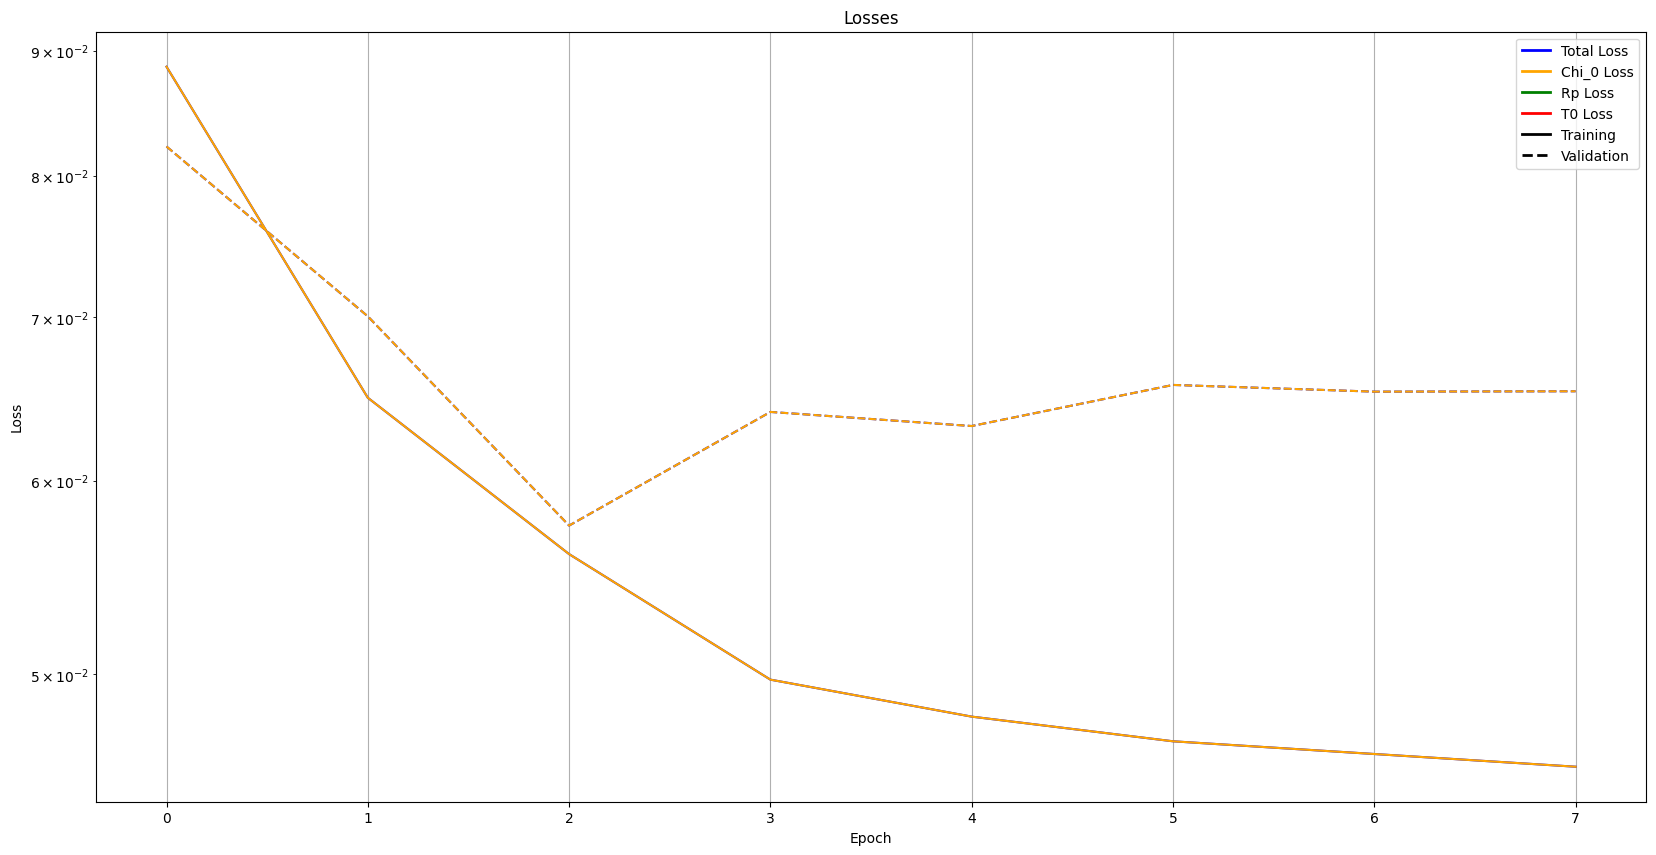

In [163]:
# Loss Plot
EpochLosses    = tracker.EpochLoss
EpochValLosses = tracker.EpochValLoss
Keys = list(EpochLosses.keys())
Nepochs = len(EpochLosses[Keys[0]])

ax = plt.figure(figsize=(20, 10)).gca()

# Define colors
colors = ['blue', 'orange', 'green', 'red','cyan','purple','magenta','yellow']

skip_keys = ['Rp','T0','Chi_0','Total']
skip_keys = []

custom_lines = []
custom_keys  = []
for i in range(len(Keys)):
    if Keys[i] in skip_keys: continue
    plt.plot(EpochLosses[Keys[i]]   , color=colors[i], label=Keys[i] + ' - Training')
    plt.plot(EpochValLosses[Keys[i]], color=colors[i], label=Keys[i] + ' - Validation', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2))
    custom_keys.append(Keys[i]+' Loss')

custom_lines+= [Line2D([0], [0], color='black', lw=2),
                Line2D([0], [0], color='black', lw=2, linestyle='dashed')]
custom_keys += ['Training', 'Validation']


ax.legend(custom_lines, custom_keys)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # integer ticks
ax.set_title('Losses')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.grid()

In [164]:
# Define some metrics
def MeanSquaredError(Truths,Predictions):
    return ((Truths-Predictions)**2).mean()
def MeanAbsoluteError(Truths,Predictions):
    return (np.abs(Truths-Predictions)).mean() if type(Truths) != torch.Tensor else (torch.abs(Truths-Predictions)).mean()
def Percentile68(Truths,Predictions):
    return np.percentile(np.abs(Truths-Predictions),68) if type(Truths) != torch.Tensor else torch.quantile(torch.abs(Truths-Predictions),0.68)

In [165]:
# Compute the Test Set
print(f'Computing Test Set for model {model.Name}') 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Test'
Dataset.BatchSize  = len(Dataset)//256
# Dataset.BatchSize = 1
# Dataset.BatchSize  = 64
Dataset.RandomIter = False
Truth_Has_Been_Unnormalised = False

Truth   = []
Rec     = []
Pred    = []
PredChis= []
PredGeom= []
Mains   = []
Auxs    = []

latent_spaces = []
Acc_Loss_tracks = []

model.eval()
EvI = 0
with torch.no_grad():
    for i,(EventIndex,BatchMains, BatchAux,BatchTruth,BatchRec) in enumerate(Dataset):
        if i%10==0: print(f'Batch {i} / {int(len(Dataset)/Dataset.BatchSize)}', end='\r')
        Truth .append(BatchTruth)
        Rec   .append(BatchRec)
        Mains .append(deepcopy(BatchMains))

        Auxs  .append(BatchAux)

        if model.Name in ['Model_Autoencoder_TimeFit',] :
            Model_Out = model(BatchMains, BatchAux)

            Pred     .append(Model_Out['time_profile'].cpu())
            PredChis .append(Model_Out['test_chi_is' ].cpu())
            PredGeom .append(Model_Out['geometry'    ].cpu())
            latent_spaces.append(Model_Out['latent_space'].cpu())
            Acc_Loss_tracks.append(Model_Out['Acc_Loss_track'])
        
        if model.Name in ['Model_Latent_Iterator_only_geometry','Model_Latent_Iterator'] :
            Model_Out = model(BatchMains, BatchAux)

            PredGeom .append(Model_Out['geometry'    ].cpu())
            # latent_spaces.append(Model_Out['latent_space'].cpu())
            # Acc_Loss_tracks.append(Model_Out['Acc_Loss_track'])
        
        EvI+=1
        # if EvI == 10: break

print()
Truth   = torch.cat(Truth   , dim=0) if len(Truth) > 0 else torch.tensor([])
Rec     = torch.cat(Rec     , dim=0) if len(Rec) > 0 else torch.tensor([])
Pred    = torch.cat(Pred    , dim=0) if len(Pred) > 0 else torch.tensor([])
PredChis= torch.cat(PredChis, dim=0) if len(PredChis) > 0 else torch.tensor([])
PredGeom= torch.cat(PredGeom, dim=0) if len(PredGeom) > 0 else torch.tensor([])
Auxs    = torch.cat(Auxs    , dim=0) if len(Auxs) > 0 else torch.tensor([])

latent_spaces = torch.cat(latent_spaces, dim=0) if len(latent_spaces) > 0 else torch.tensor([])
Acc_Loss_tracks = torch.tensor(Acc_Loss_tracks) if len(Acc_Loss_tracks) > 0 else torch.tensor([])


Truth   = Truth.numpy()
Rec     = Rec  .numpy()
Pred    = Pred .numpy()
PredChis= PredChis.numpy()
PredGeom= PredGeom.numpy()
Auxs    = Auxs .numpy()

latent_spaces = latent_spaces.numpy()
Acc_Loss_tracks = Acc_Loss_tracks.numpy()


print(Truth.shape)
print(Pred.shape)
print(PredChis.shape)
print(PredGeom.shape)
print()
print(latent_spaces.shape)
print(Acc_Loss_tracks.shape)

chi_is = []
charge = []
times  = []

station_chii = []
station_time = []
station_signal = []

norm_min_time = []



for Batch in Mains:
    for Main in Batch:
        chi_is.append(Main['chi_is'].numpy())
        charge.append(Main['charge'].numpy())
        times  .append(Main['time']  .numpy())

        station_chii.append(Main['station_chii'].item())
        station_time.append(Main['station_time'].item())
        station_signal.append(Main['station_signal'].item())

        norm_min_time.append(Main['norm_min_time'])

station_time   = np.array(station_time)
station_signal = np.array(station_signal)
station_chii   = np.array(station_chii)

norm_min_time = np.array(norm_min_time)

print(f'Station Measurements lengths: {len(station_time)}, {len(station_signal)}, {len(station_chii)}')
print(f'Total Mains split into showers = {len(chi_is)}')
        

Computing Test Set for model Model_Latent_Iterator
Batch 250 / 256
(81611, 3)
(0,)
(0,)
(81611, 3)

(0,)
(0,)
Station Measurements lengths: 81611, 81611, 81611
Total Mains split into showers = 81611


In [166]:
def time_fit(chii,chi_0,Rp,T0):
    
    in_tan  = (chi_0 - chii)/2
    scale = Rp/(3e8)
    time_profile = T0/1e9 + scale*torch.tan(in_tan)
    return time_profile*1e7 # return in 100ns units - telescope bins
    

def time_fit_np(chii,chi_0,Rp,T0):
    
    in_tan  = (chi_0 - chii)/2
    scale = Rp/(3e8)
    time_profile = T0/1e9 + scale*np.tan(in_tan)
    return time_profile*1e7 # return in 100ns units - telescope bins




In [167]:
# Unnormalise Geometry Values
if not Truth_Has_Been_Unnormalised:
    Truth = Dataset.Unnormalise_Truth(torch.tensor(Truth)).numpy()
    PredGeom = Dataset.Unnormalise_Truth(torch.tensor(PredGeom)).numpy()
    Truth_Has_Been_Unnormalised = True
    print('Truth has been unnormalised')
else:
    print('Truth has already been unnormalised, skipping unnormalisation step')

Truth has been unnormalised


# Comparing Time Profile Predictions

In [168]:
# Generate the Truth Data

Chi_0s = Truth[:,0]
Rp     = Truth[:,1]
T0     = Truth[:,2]

test_chis = np.linspace(0, 1, num=100).reshape(1, -1).repeat(len(Pred), axis=0)  # (B, 10) # between 0 and 1
test_chis = test_chis * np.ones_like(Chi_0s[:, np.newaxis])*np.pi  # (B, 10) # between 0 and chi_0

Time_Profile_Truth  = time_fit_np(test_chis, Chi_0s[:, np.newaxis], Rp[:, np.newaxis], T0[:, np.newaxis])  # (B, 10)
Time_Profile_Pred   = Pred[:,:,0]  # (B, 10)
Chii_Profile_Truth  = test_chis  # (B, 10)
Chii_Profile_Pred   = PredChis[:,:,0]

print(f'Time Profile Truth Shape: {Time_Profile_Truth.shape}')
print(f'Time Profile Pred Shape: {Time_Profile_Pred.shape}')



ValueError: operands could not be broadcast together with shapes (0,100) (81611,1) 

Latent Space for Event 74148: [-3.1276321   5.3466053   0.18106145  0.8996354   0.8332889  -7.0201235
  2.9114003   6.1808233  -6.8408318  -5.8506875  -8.130529   -6.753701
  3.216642   -1.6182983  -8.210682   -0.49352568]
Truth for Event 74148: Chi_0=1.6867949962615967, Rp=12471.671875, T0=4131.87646484375
Pred  for Event 74148: Chi_0=1.5707963705062866, Rp=0.0, T0=0.0


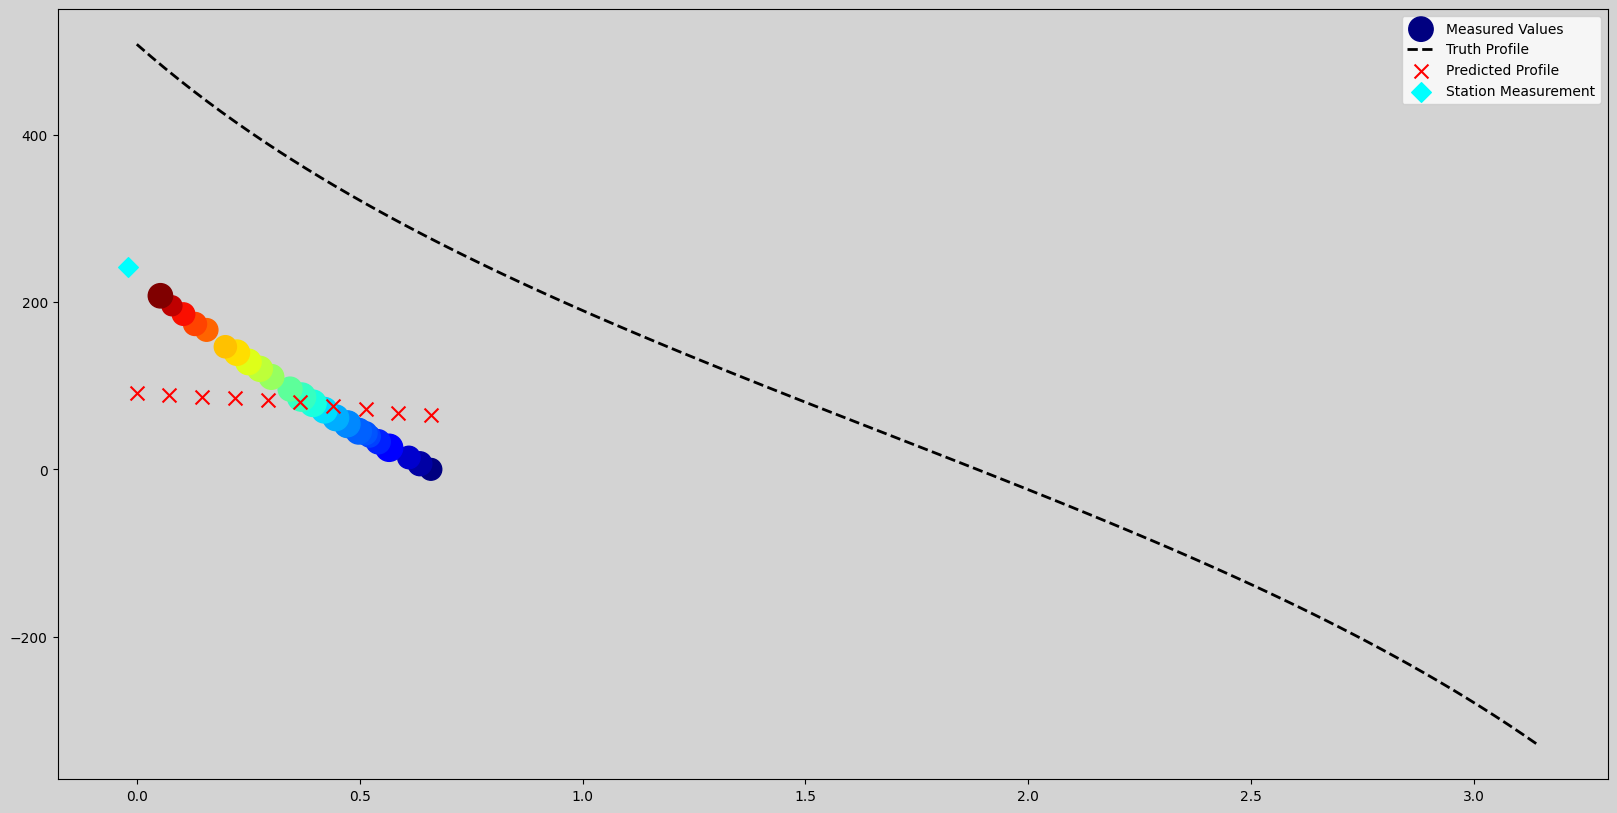

In [ ]:
Event_Found = False
while not Event_Found:
    N = np.random.randint(0, len(Pred))
    if len(chi_is[N]) > 10: Event_Found = True


fig, ax = plt.subplots(1,1,figsize=(20, 10))
ax.set_facecolor('lightgray')
fig.set_facecolor('lightgray')

t_chii = chi_is[N]
t_charge = charge[N]
t_time   = times[N]

t_station_chii = station_chii[N]
t_station_time = station_time[N]


t_norm_min_time = norm_min_time[N] 

t_chii_preds = Chii_Profile_Pred[N]
t_chii_truth = Chii_Profile_Truth[N]
t_time_preds = Time_Profile_Pred[N]
t_time_truth = Time_Profile_Truth[N]


t_time = t_time #+ t_norm_min_time
t_time_preds = t_time_preds + t_norm_min_time


t_latent_space = latent_spaces[N]
print(f'Latent Space for Event {N}: {t_latent_space}')


t_truth = Truth[N]
t_pred  = PredGeom[N]
print(f'Truth for Event {N}: Chi_0={t_truth[0]}, Rp={t_truth[1]}, T0={t_truth[2]}')
print(f'Pred  for Event {N}: Chi_0={t_pred[0] }, Rp={t_pred[1] }, T0={t_pred[2] }')

ax.scatter(t_chii, t_time, c = t_time, cmap='jet',s=10*np.sqrt(t_charge), label='Measured Values')

ax.plot(t_chii_truth, t_time_truth, color='black', label='Truth Profile', linewidth=2, linestyle='dashed') 
# ax.scatter(Chii_Profile_Truth[N], Time_Profile_Pred[N], color='red', label='Predicted Profile', s=100)
ax.scatter(t_chii_preds, t_time_preds, color='red',marker='x', label='Predicted Profile', s=100)
ax.scatter(t_station_chii, t_station_time, color='cyan', marker='D', label='Station Measurement', s=100)

# ax.set_xlim(-0.1,1.1*max(t_chii))
# ax.set_ylim(0.9*(min(min(t_time),t_station_time)),1.1*max(t_time))
plt.legend()


In [ ]:
dir(model.produce_geometry[0])# Assuming you want to print the weights of the first layer
layer = model.produce_geometry[0]  # Access the specific layer
for param in layer.parameters():
    print(param.data)  # Print the weights/parameters


tensor([[ 0.1794,  0.0735,  0.0780,  ..., -0.0377, -0.0253, -0.1506],
        [-0.0827,  0.1256, -0.1862,  ...,  0.2392,  0.1907,  0.0288],
        [-0.1839, -0.0423, -0.2200,  ...,  0.0637,  0.0087, -0.0079],
        ...,
        [ 0.0070,  0.0892, -0.0774,  ..., -0.0261,  0.1650,  0.1769],
        [ 0.0074, -0.1198, -0.0719,  ...,  0.1010, -0.1783,  0.2346],
        [-0.1250, -0.1474, -0.0448,  ...,  0.1078, -0.0661, -0.0845]], device='cuda:0')
tensor([ 0.1710,  0.2108, -0.2330, -0.2448, -0.1720, -0.0877, -0.1795,  0.2492,  0.1727, -0.2465,  0.1081,  0.0838, -0.0902, -0.0860,  0.1727,  0.0761,  0.1469, -0.1810,  0.0697, -0.0017, -0.1300,  0.0270, -0.0690, -0.2277, -0.1226, -0.2195, -0.0705,  0.0160, -0.1211, -0.1777,  0.1466,  0.0247, -0.0101, -0.0270,  0.1689, -0.1425, -0.1203, -0.1125,  0.0380, -0.2455,  0.1497, -0.0917, -0.0742,  0.0027,  0.0504, -0.1454, -0.0494, -0.2485,  0.0197, -0.1666,  0.1081, -0.2465,  0.2429,  0.0634,  0.2433, -0.1373,
         0.0325, -0.1704, -0.2241, -0

Average Accumulated Loss Track: [0.06045784 0.00954773 0.00724434 0.922755  ]


Average Accumulated Loss Track * Iteration Weights: [0.00503815 0.0018565  0.00221355 0.38448125]


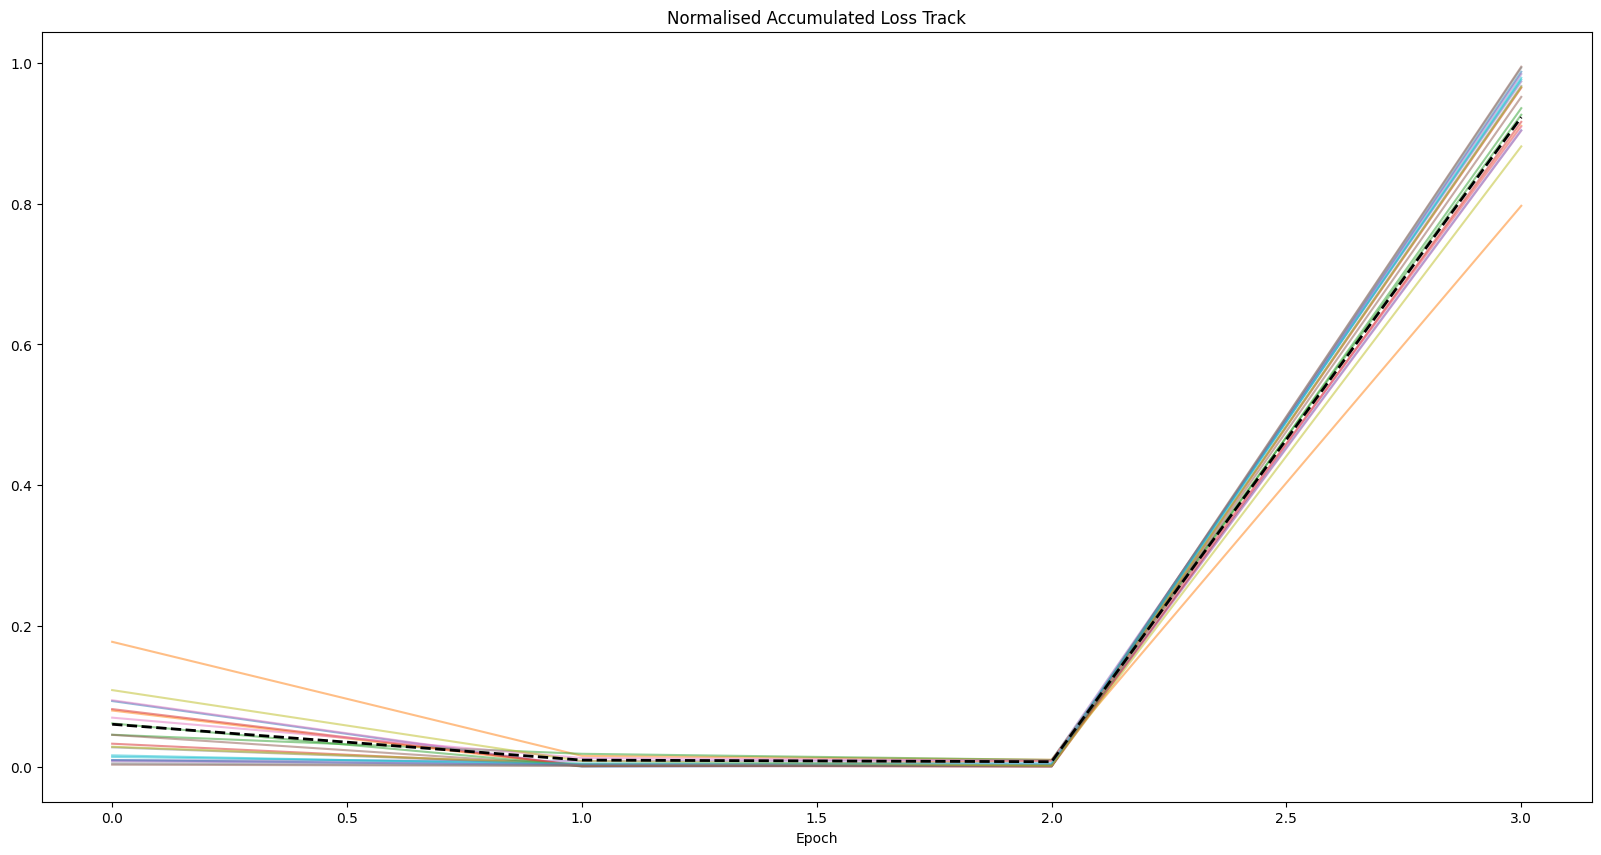

In [ ]:
iteration_weights = np.linspace(0.2,1,num=Acc_Loss_tracks.shape[1])
iteration_weights = iteration_weights / iteration_weights.sum()  # Normalize the weights to sum to 1
# Not ognna use it for anything so far


# Lets normalise the Acc_Loss_tracks
Acc_Loss_tracks_sum = Acc_Loss_tracks.sum(axis=1, keepdims=True)
Acc_Loss_tracks_norm = Acc_Loss_tracks / (Acc_Loss_tracks_sum + 1e-8)  # Add small value to avoid division by zero
# Now we can plot the Acc_Loss_tracks for the event N
fig, ax = plt.subplots(1,1,figsize=(20, 10))
plot_num = 20

for i in range(plot_num):
    ax.plot(Acc_Loss_tracks_norm[i,:], label=f'Event {i}', alpha=0.5)

Average_Acc_Loss_Track = Acc_Loss_tracks_norm.mean(axis=0)
ax.plot(Average_Acc_Loss_Track, color='black', label='Average', linewidth=2, linestyle='dashed')
ax.set_title('Normalised Accumulated Loss Track')
ax.set_xlabel('Epoch')

print(f'Average Accumulated Loss Track: {Average_Acc_Loss_Track}')
print(f'Average Accumulated Loss Track * Iteration Weights: {Average_Acc_Loss_Track * iteration_weights}')


# Comparing Geometry Predictions


Total Points before cuts 81611
Chi_0 Total Points after cuts 81610
Rp Total Points after cuts 81538
T0 Total Points after cuts 22377


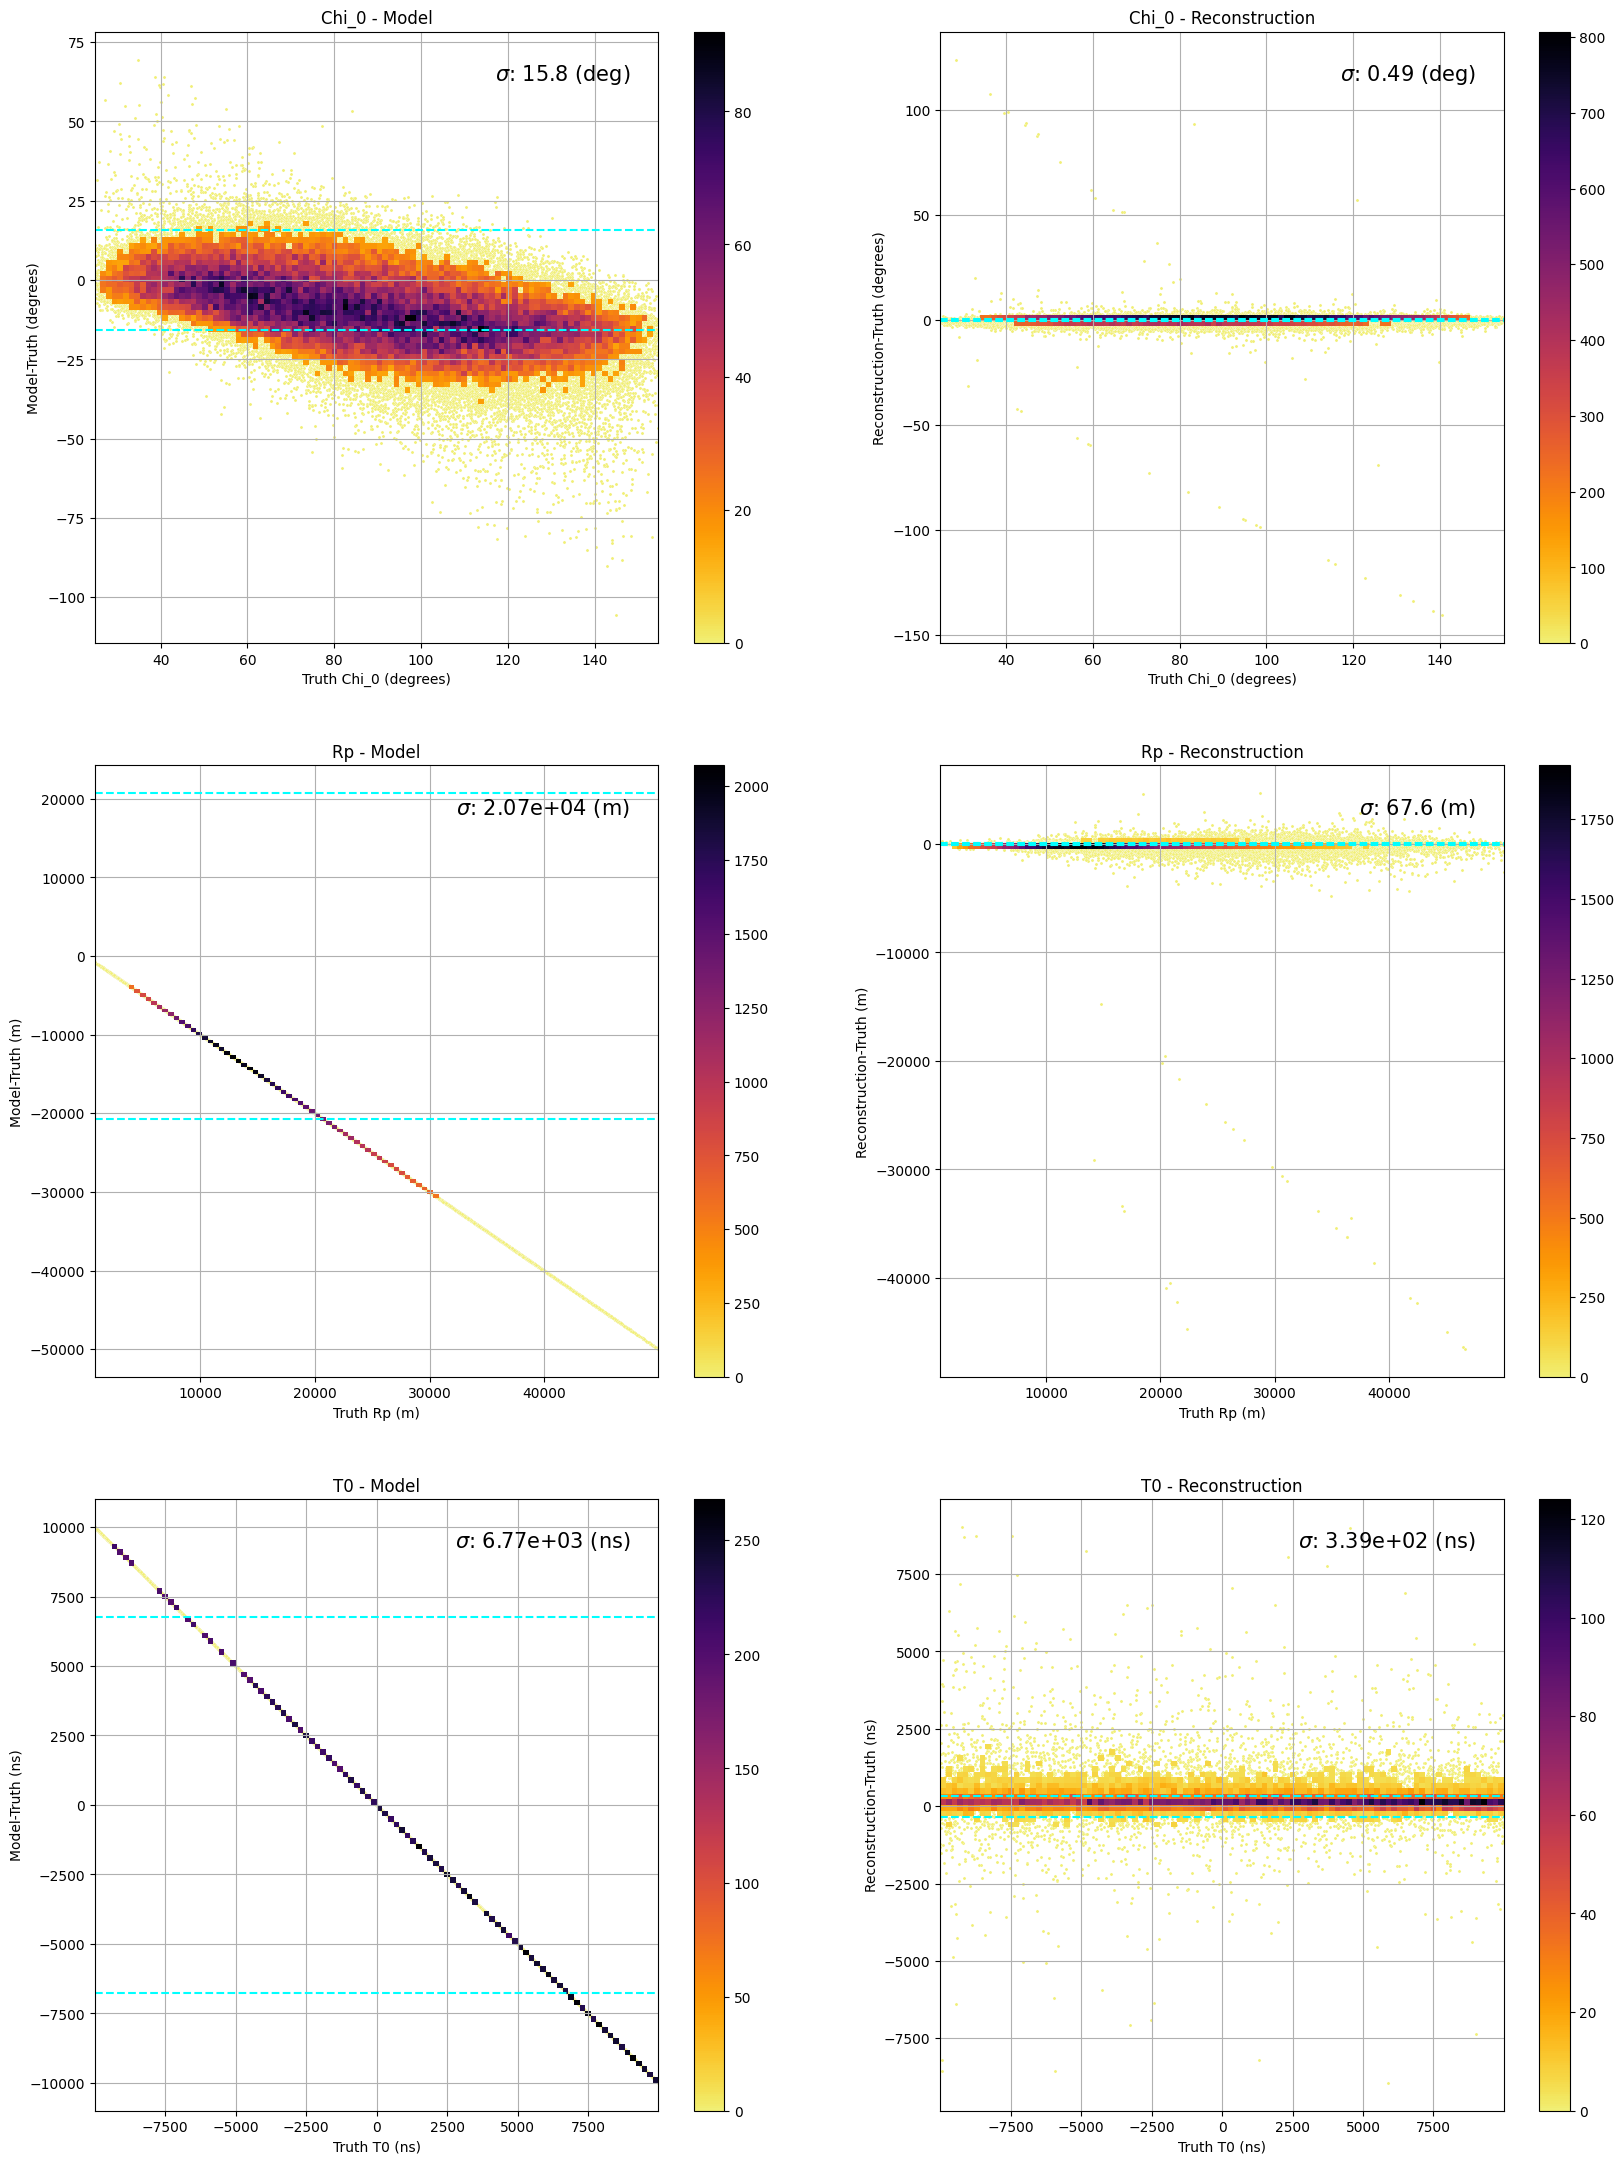

In [169]:
# Combined Deviation Plots Function Definition
from matplotlib.colors import LinearSegmentedColormap

# Create a truncated version of the inferno colormap (first 90%)
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'truncated_{cmap.name}', 
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Original inferno colormap
inferno = plt.get_cmap('inferno_r')

# Truncated colormap: first 90%
truncated_inferno = truncate_colormap(inferno, 0.05, 1)

def CombinedDeviationPlots(TruthKeys,TruthUnits,Truth,Pred,Rec):
    plt.style.use('default')
    fig, ax = plt.subplots(len(TruthKeys),2, figsize=(20,9*len(TruthKeys)))
    print(f'Total Points before cuts {len(Truth)}')
    for i in range(len(TruthKeys)):
        X  = Truth[:, i] if TruthUnits[i] != 'rad' else Truth[:, i]/np.pi*180
        Yp = Pred[:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Pred[:, i] - Truth[:, i])/np.pi*180
        Yr = Rec [:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Rec [:, i] - Truth[:, i])/np.pi*180
        
        # Scaling Cuts
        if   TruthKeys[i] == 'SDPTheta': cut = (np.abs(Yp)>0)  #& (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'SDPPhi'  : cut = (np.abs(Yp)>0)  #& (np.abs(Yp)<20)    & (np.abs(Yr)<20) #   & (np.abs(X)<50)
        elif TruthKeys[i] == 'Chi0'    : cut = (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'Rp'      : cut = (np.abs(Yp)<50000)  & (np.abs(Yr)<50000)
        elif TruthKeys[i] == 'CEDist'  : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'T0'      : cut = (np.abs(Yp)<10000) & (np.abs(Yr)<10000)
        elif TruthKeys[i] == 'Xmax'    : cut = (np.abs(Yp)<200)   & (np.abs(Yr)<200)  & (X>100)
        elif TruthKeys[i] == 'LogE'    : cut = (X>0)             # & (np.abs(Yp)<3000)    & (np.abs(Yr)<3000)
        elif TruthKeys[i] == 'z'       : cut = (X>0.4) 
        else: cut = (np.abs(Yp)>0)

        
        X = X[cut]
        Yp = Yp[cut]
        Yr = Yr[cut]

        # Secondary Y_lim cuts for scaling
        # Yp_STD = np.percentile(np.abs(Yp),68)
        # cut = (np.abs(Yp)<5*Yp_STD) & (np.abs(Yr)<5*Yp_STD)
        # X  = X [cut]
        # Yp = Yp[cut]
        # Yr = Yr[cut]
        print(f'{TruthKeys[i]} Total Points after cuts {len(X)}')
        # sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color='orange')
        # sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color='orange')

        sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color=truncated_inferno(0))
        sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color=truncated_inferno(0))


        sns.histplot(x=X, y=Yp, ax=ax[i,0], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        sns.histplot(x=X, y=Yr, ax=ax[i,1], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        if TruthUnits[i] != 'rad': 
            ax[i,0].set_ylabel(f'Model-Truth ({TruthUnits[i]})')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            ax[i,1].set_ylabel(f'Reconstruction-Truth ({TruthUnits[i]})')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            
        else:                      
            ax[i,0].set_ylabel(f'Model-Truth (degrees)')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')

            ax[i,1].set_ylabel(f'Reconstruction-Truth (degrees)')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')
        
        ax[i,0].set_title(f'{TruthKeys[i]} - Model')
        ax[i,1].set_title(f'{TruthKeys[i]} - Reconstruction')

        ax[i,0].set_xlim(min(X),max(X))
        ax[i,1].set_xlim(min(X),max(X))

        ax[i,0].grid()
        ax[i,1].grid()

        # ax[0,1].set_facecolor('lightgrey')
        # ax[1,1].set_facecolor('lightgrey')


        # 68th Percentile
        Percentile68_p = np.percentile(np.abs(Yp),68)
        Percentile68_r = np.percentile(np.abs(Yr),68)

        # ax[i,0].set_ylim(-Percentile68_p*5,Percentile68_p*5)
        # ax[i,1].set_ylim(-Percentile68_p*5,Percentile68_p*5)



        # Add as a texbox to top right of plot
        if TruthUnits[i]!= 'rad':
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)

        else:
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)



        ax[i,0].axhline(Percentile68_p, color='cyan', linestyle='--')
        ax[i,0].axhline(-Percentile68_p, color='cyan', linestyle='--')

        ax[i,1].axhline(Percentile68_r, color='cyan', linestyle='--')
        ax[i,1].axhline(-Percentile68_r, color='cyan', linestyle='--')
        
    return fig


fig = CombinedDeviationPlots(Dataset.Truth_Keys,Dataset.Truth_Units,Truth,PredGeom,Rec)